In [1]:
import pandas as pd

# load the data
df = pd.read_csv(r"./travel_data_b.csv")
df.head()

,Day,Time of Day,Holiday,Travel Purpose,Weather,Traffic Conditions,Mode of Transport,Distance (km),Travel Time (min)
0,Saturday,Morning,No,Shopping,Clear,Moderate,Car,5,15
1,Saturday,Afternoon,No,Leisure,Clear,Light,Bike,10,30
2,Sunday,Morning,No,Leisure,Rainy,Light,Car,8,20
3,Monday,Morning,No,Work,Clear,Heavy,Bus,12,45
4,Monday,Evening,No,Work,Clear,Heavy,Bus,12,50


### Exploratory Data Analysis

In [2]:
# Descriptive statistics of the dataset
eda_summary = df.describe()
eda_summary

,Distance (km),Travel Time (min)
count,34.000000,34.000000
mean,8.882353,34.294118
std,3.867226,14.644328
min,2.000000,15.000000
25%,6.000000,20.000000
50%,10.000000,31.000000
75%,12.000000,47.250000
max,15.000000,60.000000


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')
%matplotlib inline

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Day                 34 non-null     object
 1   Time of Day         34 non-null     object
 2   Holiday             34 non-null     object
 3   Travel Purpose      34 non-null     object
 4   Weather             34 non-null     object
 5   Traffic Conditions  34 non-null     object
 6   Mode of Transport   34 non-null     object
 7   Distance (km)       34 non-null     int64 
 8   Travel Time (min)   34 non-null     int64 
dtypes: int64(2), object(7)
memory usage: 2.5+ KB


In [5]:
df.describe()

,Distance (km),Travel Time (min)
count,34.000000,34.000000
mean,8.882353,34.294118
std,3.867226,14.644328
min,2.000000,15.000000
25%,6.000000,20.000000
50%,10.000000,31.000000
75%,12.000000,47.250000
max,15.000000,60.000000


In [6]:
df.isnull().sum()

Day                   0
Time of Day           0
Holiday               0
Travel Purpose        0
Weather               0
Traffic Conditions    0
Mode of Transport     0
Distance (km)         0
Travel Time (min)     0
dtype: int64

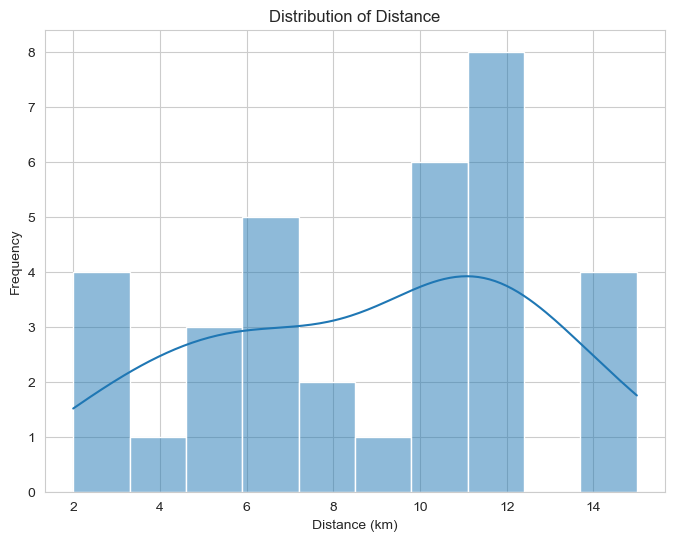

In [7]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance (km)'], bins=10, kde=True)
plt.title('Distribution of Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.show()

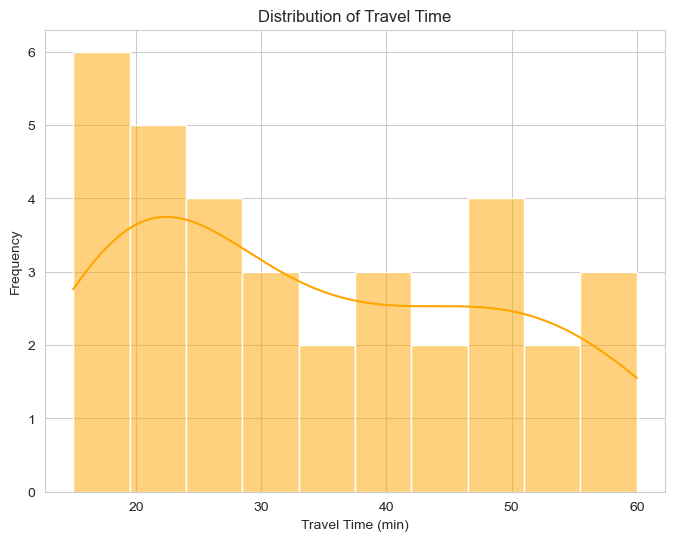

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Travel Time (min)'], bins=10, kde=True, color='orange')
plt.title('Distribution of Travel Time')
plt.xlabel('Travel Time (min)')
plt.ylabel('Frequency')
plt.show()

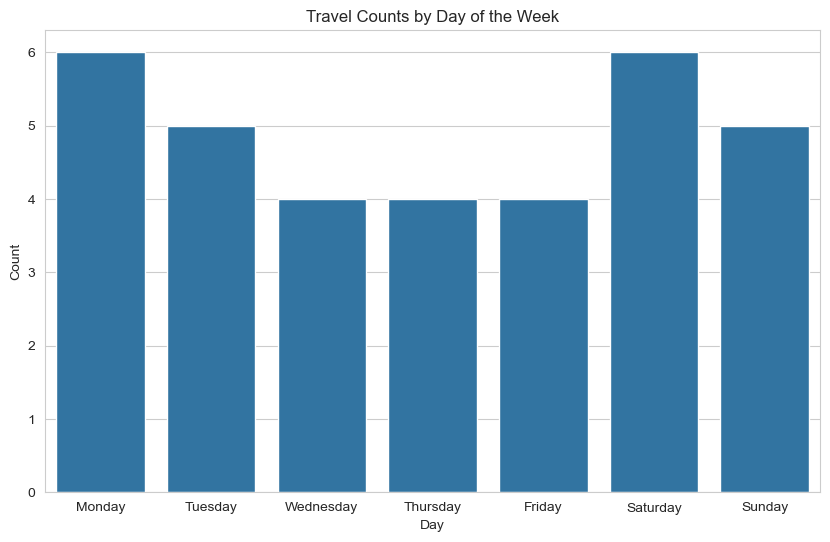

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Day', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Travel Counts by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.show()

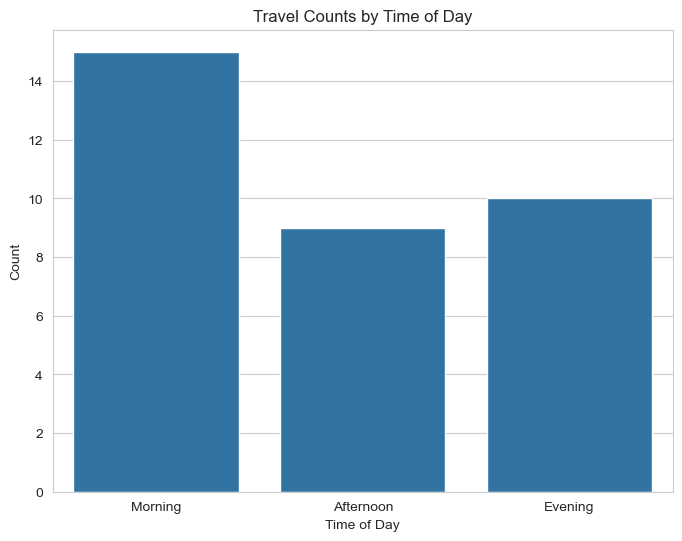

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Time of Day', order=['Morning', 'Afternoon', 'Evening'])
plt.title('Travel Counts by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.show()

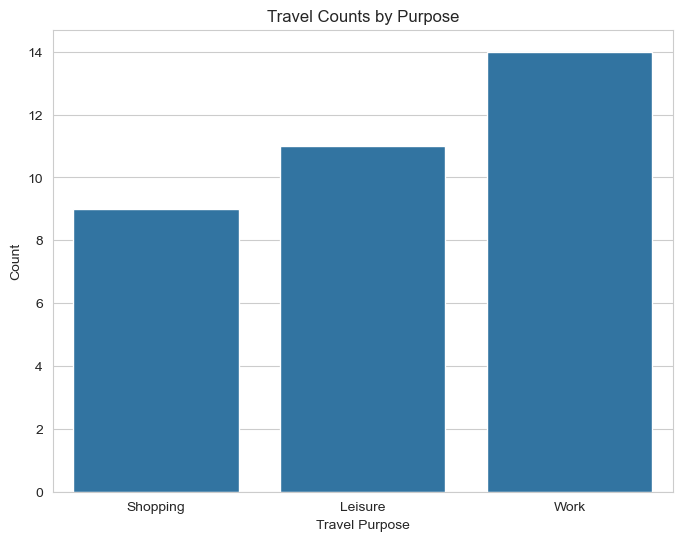

In [11]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Travel Purpose')
plt.title('Travel Counts by Purpose')
plt.xlabel('Travel Purpose')
plt.ylabel('Count')
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

categorical_cols = ['Day', 'Time of Day', 'Holiday', 'Travel Purpose', 'Weather', 'Traffic Conditions', 'Mode of Transport']

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

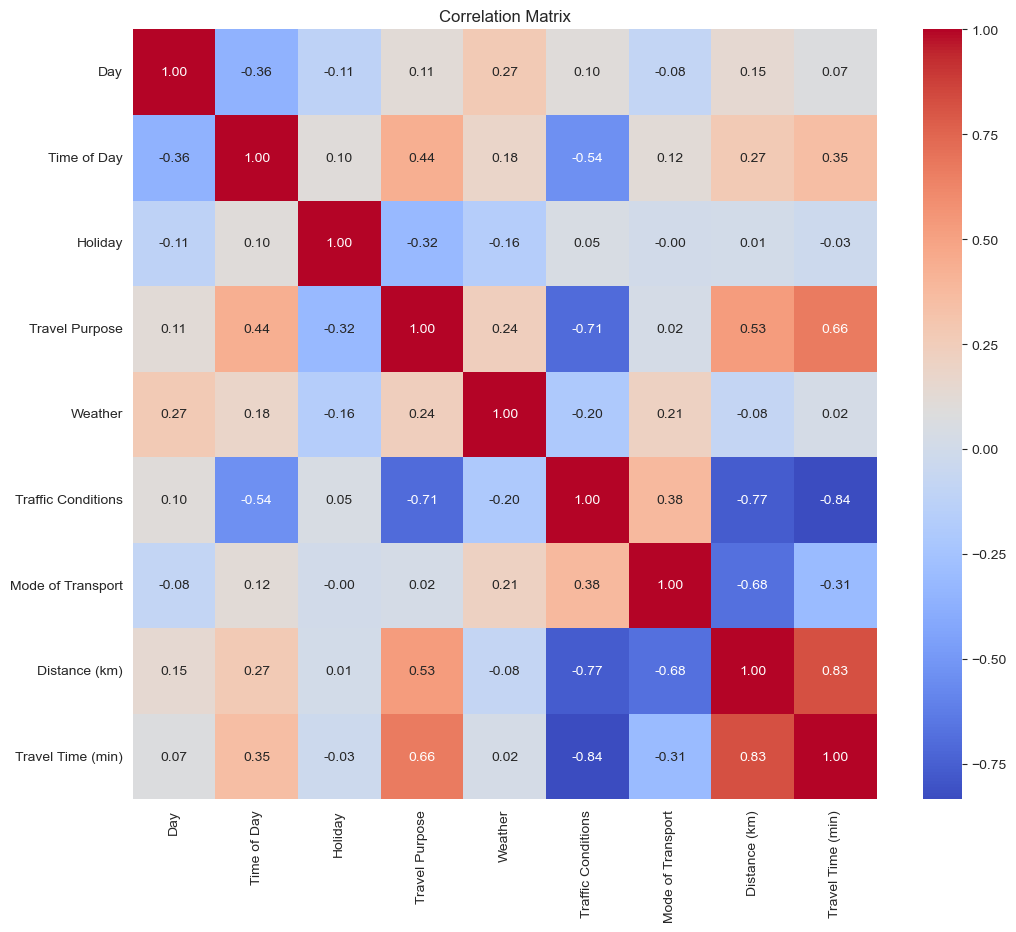

In [13]:
plt.figure(figsize=(12, 10))
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

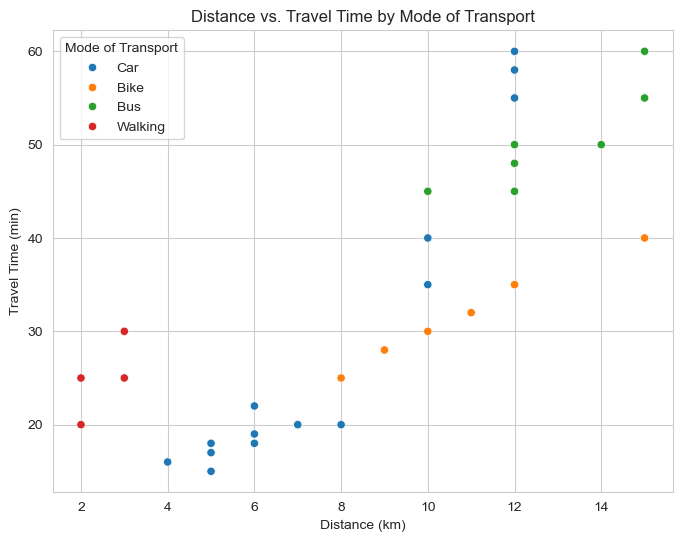

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Distance (km)', y='Travel Time (min)', hue='Mode of Transport')
plt.title('Distance vs. Travel Time by Mode of Transport')
plt.xlabel('Distance (km)')
plt.ylabel('Travel Time (min)')
plt.legend(title='Mode of Transport')
plt.show()

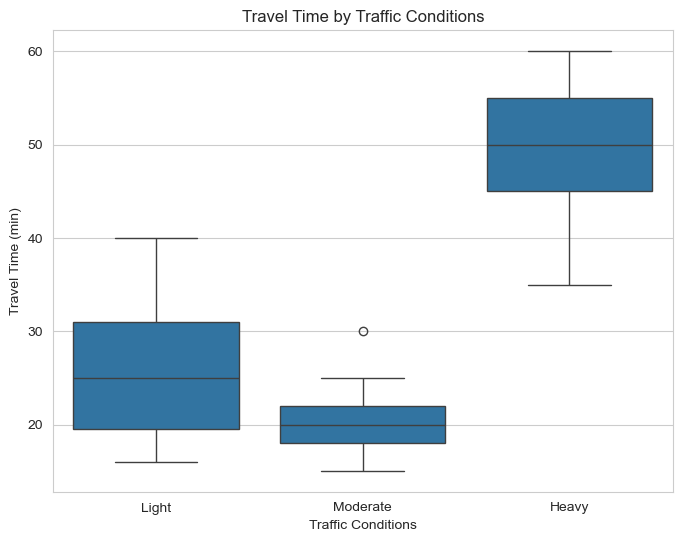

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Traffic Conditions', y='Travel Time (min)', order=['Light', 'Moderate', 'Heavy'])
plt.title('Travel Time by Traffic Conditions')
plt.xlabel('Traffic Conditions')
plt.ylabel('Travel Time (min)')
plt.show()

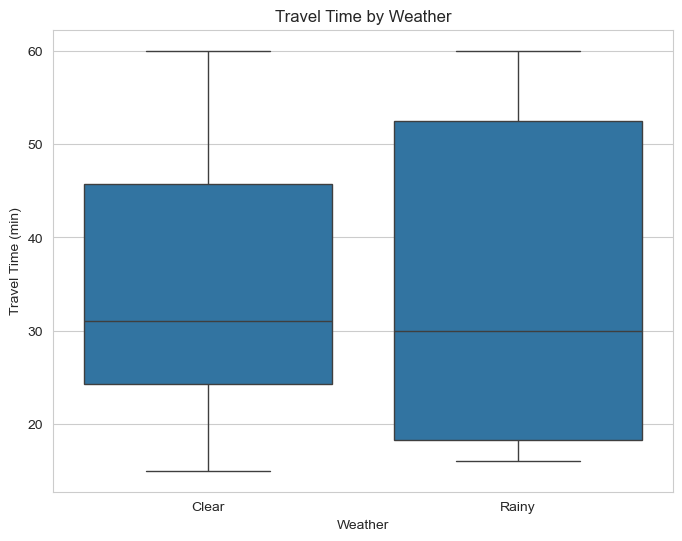

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Weather', y='Travel Time (min)')
plt.title('Travel Time by Weather')
plt.xlabel('Weather')
plt.ylabel('Travel Time (min)')
plt.show()

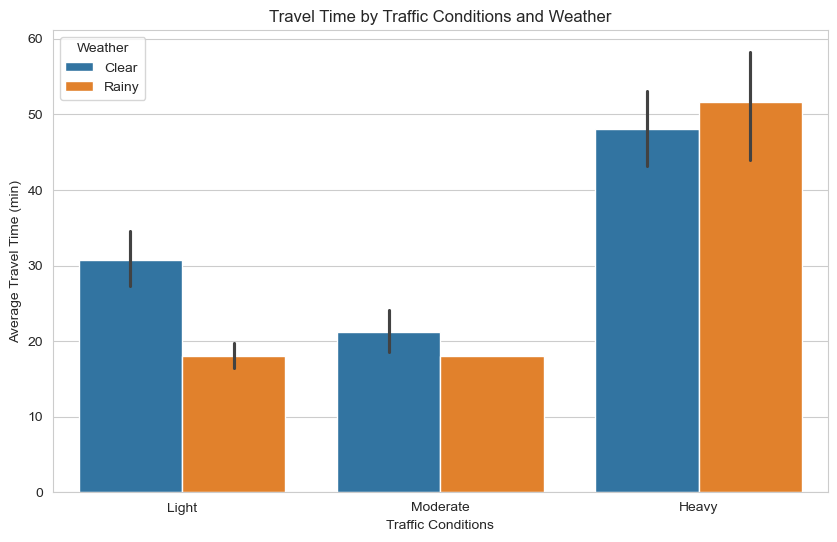

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Traffic Conditions', y='Travel Time (min)', hue='Weather', order=['Light', 'Moderate', 'Heavy'])
plt.title('Travel Time by Traffic Conditions and Weather')
plt.xlabel('Traffic Conditions')
plt.ylabel('Average Travel Time (min)')
plt.legend(title='Weather')
plt.show()

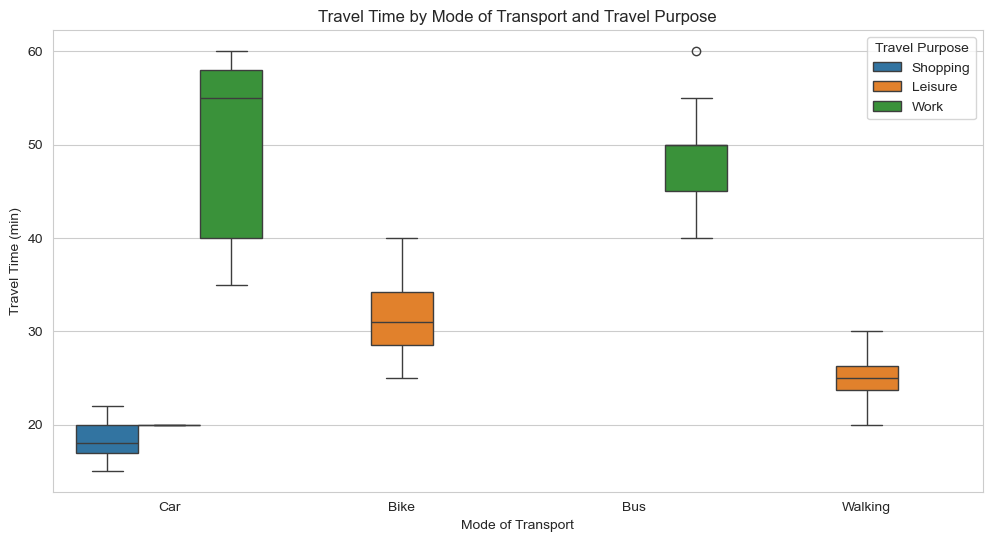

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Mode of Transport', y='Travel Time (min)', hue='Travel Purpose')
plt.title('Travel Time by Mode of Transport and Travel Purpose')
plt.xlabel('Mode of Transport')
plt.ylabel('Travel Time (min)')
plt.legend(title='Travel Purpose')
plt.show()

/Users/soumyajitpal/packages/miniconda3/envs/ml_dlai_metal/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


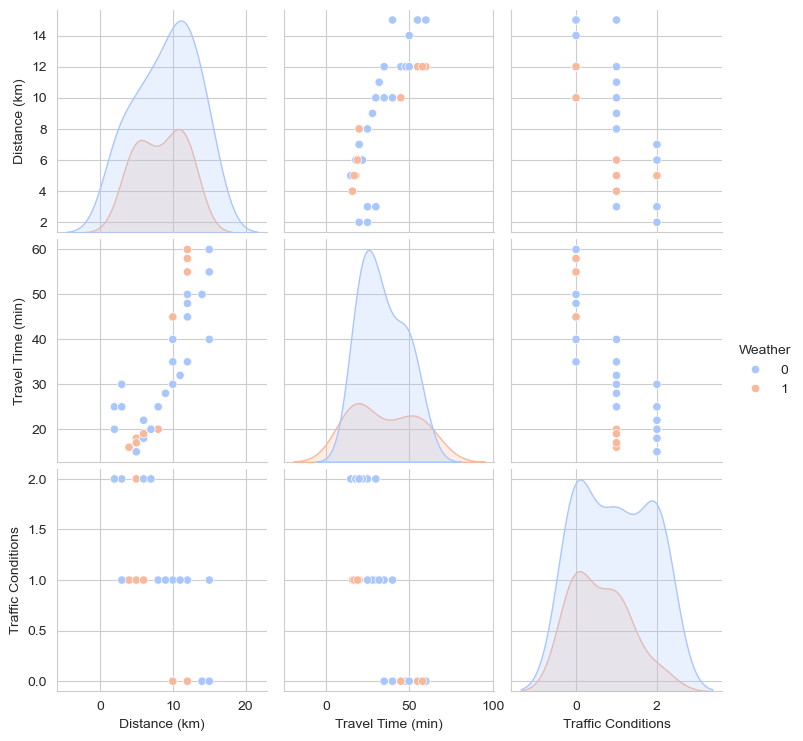

In [19]:
sns.pairplot(df_encoded[['Distance (km)', 'Travel Time (min)', 'Weather', 'Traffic Conditions']], hue='Weather', palette='coolwarm')
plt.show()

- Distance and Travel Time: Strong positive correlation; as distance increases, travel time increases. 

- Traffic Conditions: Heavier traffic leads to longer travel times. 

- Weather Impact: Rainy weather is associated with longer travel times, possibly due to cautious driving and traffic delays. 

- Mode of Transport: Travel time varies significantly with the mode of transport. Walking and biking are slower over longer distances. 

- Travel Purpose: Work-related travels tend to have longer travel times, possibly due to longer distances and peak traffic hours. 

### Prepare the data

In [20]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score
from scipy.special import gammaln 

In [21]:
categorical_cols = [
    'Day', 'Time of Day', 'Holiday', 'Travel Purpose',
    'Weather', 'Traffic Conditions', 'Mode of Transport'
]
numerical_cols = ['Distance (km)']

In [22]:
# Initialize OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)

# Apply ColumnTransformer to handle both numerical and categorical features
from sklearn.compose import make_column_transformer

preprocessor = make_column_transformer(
    (ohe, categorical_cols),
    remainder='passthrough'  # Keep the numerical columns as they are
)

# Fit and transform the data
X_encoded = preprocessor.fit_transform(df.drop(['Travel Time (min)'], axis=1))

# Get feature names after encoding
encoded_feature_names = preprocessor.named_transformers_['onehotencoder'].get_feature_names_out(categorical_cols)
all_feature_names = list(encoded_feature_names) + numerical_cols

In [23]:
# Features
X = pd.DataFrame(X_encoded, columns=all_feature_names)

# Target variable
y = df['Travel Time (min)']

#### split the datasets

In [24]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Poisson Regression

#### Maximum Likelihood Estimation (MLE)

In [25]:
def log_likelihood(beta, X, y):
    X_beta = X @ beta
    lambda_ = np.exp(X_beta)
    # Compute log-likelihood
    ll = np.sum(y * X_beta - lambda_ - gammaln(y + 1))
    return ll

In [26]:
def gradient(beta, X, y):
    X_beta = X @ beta
    lambda_ = np.exp(X_beta)
    grad = X.T @ (y - lambda_)
    return grad

In [27]:
def gradient_ascent(X, y, learning_rate=0.001, max_iter=1000, tol=1e-6):
    n_features = X.shape[1]
    beta = np.zeros(n_features)  # Initialize beta
    ll_old = log_likelihood(beta, X, y)
    
    for iteration in range(max_iter):
        grad = gradient(beta, X, y)
        beta += learning_rate * grad  # Update rule
        
        # Check convergence
        ll_new = log_likelihood(beta, X, y)
        if np.abs(ll_new - ll_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        ll_old = ll_new
    return beta

In [28]:
beta_mle = gradient_ascent(X_train, y_train, learning_rate=0.0001)
print("Estimated parameters (MLE):")
print(beta_mle)

Estimated parameters (MLE):
Day_Monday                     15.399288
Day_Saturday                   11.015407
Day_Sunday                      7.660057
Day_Thursday                  -32.478950
Day_Tuesday                     8.672061
Day_Wednesday                   7.313950
Time of Day_Evening            18.559213
Time of Day_Morning           -10.098136
Holiday_Yes                   -23.774607
Travel Purpose_Shopping        14.386663
Travel Purpose_Work            16.750133
Weather_Rainy                  18.927948
Traffic Conditions_Light       -8.384433
Traffic Conditions_Moderate    13.714053
Mode of Transport_Bus           3.698362
Mode of Transport_Car          29.346441
Mode of Transport_Walking       6.997278
Distance (km)                 -35.913692
dtype: float64


#### Maximum A Posteriori (MAP)

In [29]:
def log_posterior(beta, X, y, sigma2=10):
    ll = log_likelihood(beta, X, y)
    prior = - (1 / (2 * sigma2)) * np.sum(beta[1:] ** 2)  # Exclude intercept from regularization
    return ll + prior

In [30]:
def gradient_map(beta, X, y, sigma2=10):
    grad_ll = gradient(beta, X, y)
    grad_prior = - (1 / sigma2) * beta
    grad_prior[0] = 0  # Do not regularize the intercept term
    return grad_ll + grad_prior

In [31]:
def gradient_ascent_map(X, y, learning_rate=0.001, max_iter=1000, tol=1e-6, sigma2=10):
    n_features = X.shape[1]
    beta = np.zeros(n_features)  # Initialize beta
    ll_old = log_posterior(beta, X, y, sigma2)
    
    for iteration in range(max_iter):
        grad = gradient_map(beta, X, y, sigma2)
        beta += learning_rate * grad  # Update rule
        
        # Check convergence
        ll_new = log_posterior(beta, X, y, sigma2)
        if np.abs(ll_new - ll_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        ll_old = ll_new
    return beta

In [32]:
beta_map = gradient_ascent_map(X_train, y_train, learning_rate=0.0001, sigma2=10)
print("Estimated parameters (MAP):")
print(beta_map)

Estimated parameters (MAP):
Day_Monday                     15.399288
Day_Saturday                   10.962967
Day_Sunday                      7.639452
Day_Thursday                  -32.099472
Day_Tuesday                     8.644377
Day_Wednesday                   7.290839
Time of Day_Evening            18.495245
Time of Day_Morning            -9.772542
Holiday_Yes                   -23.506328
Travel Purpose_Shopping        14.315601
Travel Purpose_Work            16.819512
Weather_Rainy                  18.862795
Traffic Conditions_Light       -8.172915
Traffic Conditions_Moderate    13.646204
Mode of Transport_Bus           3.801777
Mode of Transport_Car          29.232300
Mode of Transport_Walking       6.962457
Distance (km)                 -31.304780
dtype: float64


In [33]:
def predict_poisson(X, beta):
    lambda_ = np.exp(X @ beta)
    return lambda_

In [34]:
lambda_val_mle = predict_poisson(X_test, beta_mle)
y_pred_mle = np.round(lambda_val_mle)  # Round to nearest integer

##### prediction and evaluation (poisson) MLE

In [35]:
lambda_val_map = predict_poisson(X_test, beta_map)
y_pred_map = np.round(lambda_val_map)

In [36]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred_mle)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_mle)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_mle)


print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"R2 Score: {r2:.2f} minutes")

Mean Absolute Error (MAE): 41.86 minutes
Mean Squared Error (MSE): 1965.57
Root Mean Squared Error (RMSE): 44.33 minutes
R2 Score: -8.20 minutes


#### MAP

In [37]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred_map)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_map)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_map)


print(f"Mean Absolute Error (MAE): {mae:.5f} minutes")
print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f} minutes")
print(f"R2 Score: {r2:.5f} minutes")

Mean Absolute Error (MAE): 41.85714 minutes
Mean Squared Error (MSE): 1965.57143
Root Mean Squared Error (RMSE): 44.33477 minutes
R2 Score: -8.20422 minutes


### Gamma Regression

In [38]:
k = 1.0  # Initial estimate

def gamma_log_likelihood(beta, X, y, k):
    mu = np.exp(X @ beta)
    ll = (k - 1) * np.sum(np.log(y)) - np.sum(k * y / mu) - k * np.sum(np.log(mu))
    return ll

def gamma_gradient(beta, X, y, k):
    mu = np.exp(X @ beta)
    grad = k * X.T @ ((y / mu - 1))
    return grad

def gradient_ascent_gamma(X, y, k, beta_init=None, learning_rate=0.0001, max_iter=1000, tol=1e-6):
    if beta_init is None:
        beta = np.zeros(X.shape[1])
    else:
        beta = beta_init
    ll_old = gamma_log_likelihood(beta, X, y, k)
    
    for iteration in range(max_iter):
        grad = gamma_gradient(beta, X, y, k)
        beta += learning_rate * grad
        
        ll_new = gamma_log_likelihood(beta, X, y, k)
        if np.abs(ll_new - ll_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        ll_old = ll_new
    return beta

def estimate_k(y, mu_pred):
    n = len(y)
    residuals = y - mu_pred
    variance = np.var(residuals)
    mean_mu = np.mean(mu_pred)
    k_est = (mean_mu ** 2) / variance
    return k_est



In [39]:
# Initialize beta
beta = np.zeros(X_train.shape[1])

# Set learning rate and maximum iterations
learning_rate = 0.0001
max_iter = 1000
tol = 1e-6

# Iterative procedure
for iteration in range(10):  # Limit iterations to prevent infinite loops
    print(f"Iteration {iteration + 1}")
    
    # Step 1: Estimate beta given k
    beta = gradient_ascent_gamma(X_train, y_train, k, beta_init=beta, learning_rate=learning_rate, max_iter=max_iter, tol=tol)
    
    # Step 2: Estimate k given beta
    mu_pred = np.exp(X_train @ beta)
    k_new = estimate_k(y_train, mu_pred)
    
    print(f"k estimate: {k_new}")
    
    # Check for convergence
    if np.abs(k_new - k) < tol:
        print("Converged on k")
        break
    k = k_new

Iteration 1
k estimate: 2.178732978492082
Iteration 2
k estimate: 5.631463300576948
Iteration 3
k estimate: 14.675943736333606
Iteration 4
k estimate: 0.7156279210483314
Iteration 5
k estimate: 28.522313860569415
Iteration 6
k estimate: 0.06710928345237069
Iteration 7
k estimate: 2.012891924218661
Iteration 8
k estimate: 12.075380607514385
Iteration 9
k estimate: 0.9453075315522735
Iteration 10
k estimate: 46.952344787954566


In [40]:
# Predict mu for validation set
y_pred_gamma = np.exp(X_test @ beta)

In [41]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred_gamma)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_gamma)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_gamma)


print(f"Mean Absolute Error (MAE): {mae:.5f} minutes")
print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f} minutes")
print(f"R2 Score: {r2:.5f} minutes")

Mean Absolute Error (MAE): 6.94722 minutes
Mean Squared Error (MSE): 62.57375
Root Mean Squared Error (RMSE): 7.91036 minutes
R2 Score: 0.70698 minutes


### Linear Regression

In [42]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

LinearRegression()

In [43]:
# Predict on the test set
y_pred = model.predict(X_test)

In [44]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"R2 Score: {r2:.2f} minutes")

Mean Absolute Error (MAE): 4.07 minutes
Mean Squared Error (MSE): 20.35
Root Mean Squared Error (RMSE): 4.51 minutes
R2 Score: 0.90 minutes


In [45]:
# Get the coefficients
coefficients = model.coef_
feature_names = X.columns

# Create a DataFrame to display coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficients
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df.sort_values(by='Abs_Coefficient', ascending=False, inplace=True)

print(coef_df[['Feature', 'Coefficient']])

                        Feature  Coefficient
16    Mode of Transport_Walking    42.479446
5                 Day_Wednesday    19.183518
1                  Day_Saturday    18.399304
2                    Day_Sunday    16.247555
4                   Day_Tuesday    12.109702
0                    Day_Monday    11.115780
10          Travel Purpose_Work    10.846354
9       Travel Purpose_Shopping     9.905796
12     Traffic Conditions_Light    -5.701687
6           Time of Day_Evening     5.227526
13  Traffic Conditions_Moderate    -5.144667
17                Distance (km)     4.848058
3                  Day_Thursday     4.459887
14        Mode of Transport_Bus    -3.151472
11                Weather_Rainy     1.990165
7           Time of Day_Morning     1.150616
15        Mode of Transport_Car    -0.752804
8                   Holiday_Yes    -0.371264
